# Teaching a Deep Q Learning Agent to Play Tetris

Adapted from [https://nostarch.com/deep-learning-crash-course](https://nostarch.com/deep-learning-crash-course)

# Python Environment Setup (Windows)
## Virtual Environment
A Python virtual environment was created to isolate project dependencies:

Using Power shell, go to your work directory for this project. 
- Create the enviroment in powershell: 
```bash 
python -m venv venv
```
- Environment activation:
```bash
.\venv\Scripts\Activate.ps1
```
- PowerShell execution policy was updated (user scope only):
```bash

Set-ExecutionPolicy -Scope CurrentUser -ExecutionPolicy RemoteSigned
```
## Installed Packages
The following packages were installed inside the virtual environment:
```bash
pip install --upgrade pip
pip install numpy
pip install matplotlib
pip install torch
pip install torchvision
pip install ipykernel
pip install pygame
```
## Jupyter / VS Code Kernel
The virtual environment was registered as a Jupyter kernel:
```bash
python -m ipykernel install --user --name venv --display-name "Python (venv)" 

This notebook provides you with a complete code example that trains a train a deep reinforcement learning model to play Tetris.

## Implementing a Simplified Tetris

Implement a class with a simplifed Tetris ...

In [38]:
import numpy as np
import random

class Tetris:
    """Simplified Tetris.
        The pieces are stored in a compact format.
        Each tile is a list of possible orientations.
        Each orientation is described column by column.

        For each column, we store an interval [y_start, y_end].
        This means that the column is occupied from y_start up to y_end - 1.
        [0, 2] means blocks at y = 0 and y = 1
        [0, 1] means one block at y = 0
    """

    TILES = [
        # Tile 0: 2-block bar
        [
            [[0, 2]],          # Orientation 0: vertical bar
                                # X
                                # X

            [[0, 1], [0, 1]],  # Orientation 1: horizontal bar
                                # X X
        ],

        # Tile 1: 2-block diagonal piece
        [
            [[1, 2], [0, 1]],  # Orientation 0:
                                # X .
                                # . X

            [[0, 1], [1, 2]],  # Orientation 1:
                                # . X
                                # X .
        ],

        # Tile 2: 3-block L-shaped piece
        [
            [[0, 2], [0, 1]],  # Orientation 0:
                                # X .
                                # X X

            [[0, 2], [1, 2]],  # Orientation 1:
                                # X X
                                # X .

            [[1, 2], [0, 2]],  # Orientation 2:
                                # X X
                                # . X

            [[0, 1], [0, 2]],  # Orientation 3:
                                # . X
                                # X X
        ],

        # Tile 3: 2x2 square
        [
            [[0, 2], [0, 2]],  # Orientation 0:
                                # X X
                                # X X
        ],
    ]

    UNDEFINED = -1

    def __init__(self, rows, cols, max_tiles, random_seed):
        """Initialize Tetris."""
        self.rows, self.cols = rows, cols
        self.max_tiles = max_tiles
        self.random_seed = random_seed

        self.restart()

    def restart(self):
        """Restart the game."""
        self.board = np.full((self.rows, self.cols), Tetris.UNDEFINED)
        self.current_tile = Tetris.UNDEFINED
        self.tile_x = Tetris.UNDEFINED
        self.tile_y = Tetris.UNDEFINED
        self.tile_orientation = Tetris.UNDEFINED

        self.gameover = False
        self.tile_count = 0

        # Create predefined tile sequence.
        rand_state = random.getstate()
        random.seed(self.random_seed)
        self.tile_sequence = [random.randint(0, len(Tetris.TILES) - 1)
                              for _ in range(self.max_tiles)]
        random.setstate(rand_state)

        self.reward = 0

        self.next_tile()

    def next_tile(self):
        """Get the next tile."""
        if self.tile_count < self.max_tiles:
            if self.random_seed is not None:
                self.current_tile = self.tile_sequence[self.tile_count]
            else:
                self.current_tile = random.randint(0, len(Tetris.TILES) - 1)

            self.tile_x = self.cols // 2
            self.tile_y = self.rows
            self.tile_orientation = 0

            self.tile_count += 1
        else:
            self.gameover = True

    def move_left(self):
        """Move current tile to the left."""
        if self.tile_x - 1 >= 0:
            self.tile_x -= 1
            return True
        else:
            return False

    def move_right(self):
        """Move current tile to the right."""
        tilewidth = len(Tetris.TILES[self.current_tile][self.tile_orientation])
        if self.tile_x + 1 <= self.cols - tilewidth:
            self.tile_x += 1
            return True
        else:
            return False

    def rotate(self):
        """Rotate current tile."""
        new_orientation = ((self.tile_orientation + 1)
                           % len(Tetris.TILES[self.current_tile]))
        tilewidth = len(Tetris.TILES[self.current_tile][new_orientation])
        if self.tile_x <= self.cols - tilewidth:
            self.tile_orientation = new_orientation
            return True
        else:
            return False

    def drop(self):
        """Drop current tile and update game board."""
        tile = Tetris.TILES[self.current_tile][self.tile_orientation]

        # Find first location where the tile collides with occupied locations.
        self.tile_y = 0
        for tile_column in range(len(tile)):
            # Tile final y position for this tile column
            # if no other columns are taken into account.
            tile_y = -1
            for y in range(self.rows - 1, -1, -1):
                if self.board[y, self.tile_x + tile_column] > 0:
                    tile_y = y + 1 - tile[tile_column][0]
                    break
            # Update tile y position.
            if tile_y > self.tile_y:
                self.tile_y = tile_y

        if self.tile_y + np.max(tile) > self.rows:
            self.gameover = True
            dreward = -100
        else:
            # Change board entries at the newly placed tile to occupied.
            for tile_column in range(len(tile)):
                self.board[self.tile_y + tile[tile_column][0]
                        :self.tile_y + tile[tile_column][1],
                        tile_column + self.tile_x] = 1

            # Remove full lines.
            removed_lines = 0
            for y in range(self.rows - 1, -1, -1):
                if np.sum(self.board[y, :]) == self.cols:
                    removed_lines += 1
                    for y1 in range(y, self.rows - 1):
                        self.board[y1, :] = self.board[y1 + 1, :]
                    self.board[self.rows - 1, :] = Tetris.UNDEFINED

            dreward = 10 ** (removed_lines - 1) if removed_lines > 0 else 0

        self.next_tile()
        self.reward += dreward
        return dreward

... and create an instance of this simplified Tetris.

In [39]:
tetris = Tetris(rows=4, cols=4, max_tiles=50, random_seed=123456)

## Playing Tetris with the Command Line

In [40]:
while not tetris.gameover:
    print(f"Tile {tetris.tile_count}/{tetris.max_tiles}")
    print(f"Reward: {tetris.reward}")
    print(f"Current tile {tetris.current_tile} with "
          f"orientation {tetris.tile_orientation} at position {tetris.tile_x}")
    print(tetris.TILES[tetris.current_tile][tetris.tile_orientation])
    print(tetris.board)

    cmd = input("Please enter your command (L, R, O, D, X): ").upper()
    print(f"Your input: {cmd} \n")

    if cmd == "L":
        tetris.move_left()
    elif cmd == "R":
        tetris.move_right()
    elif cmd == "O":
        tetris.rotate()
    elif cmd == "D":
        tetris.drop()
    elif cmd == "X":
        break

Tile 1/50
Reward: 0
Current tile 2 with orientation 0 at position 2
[[0, 2], [0, 1]]
[[-1 -1 -1 -1]
 [-1 -1 -1 -1]
 [-1 -1 -1 -1]
 [-1 -1 -1 -1]]
Your input: X 



## Playing Tetris with a Graphical Interface with Pygame

Implement a function to play Tetris with a GUI ...

In [41]:
import pygame

def play_tetris_with_gui(tetris):
    """Play Tetris with GUI for human players."""
    TILE_SIZE = 20
    BLACK = (0, 0, 0)  # RGB code for black color
    GREY = (128, 128, 128)  # RGB code for grey color
    WHITE = (255, 255, 255)  # RGB code for white color
    RED = (255, 0, 0)  # RGB code for red color

    # Initialize the game engine.
    pygame.init()
    pygame.display.set_caption("TETRIS")
    screen = pygame.display.set_mode((200 + tetris.cols * TILE_SIZE,
                                      200 + tetris.rows * TILE_SIZE))
    pygame.key.set_repeat(300, 100)  # Set keyboard delay and interval in ms
    font = pygame.font.SysFont("Calibri", 25, True)
    clock = pygame.time.Clock()
    # Loop until the window is closed.
    running = True
    while running:
        # Paint game board.
        clock.tick(30)  # limita a 30 FPS
        if pygame.display.get_active():
            screen.fill(WHITE)

            for i in range(tetris.rows):
                for j in range(tetris.cols):
                    pygame.draw.rect(screen, GREY,
                                     [100 + TILE_SIZE * j,
                                      80 + TILE_SIZE * (tetris.rows - i),
                                      TILE_SIZE, TILE_SIZE], 1)
                    if tetris.board[i][j] > 0:
                        pygame.draw.rect(screen, BLACK,
                                         [101 + TILE_SIZE * j,
                                          81 + TILE_SIZE * (tetris.rows - i),
                                          TILE_SIZE - 2, TILE_SIZE - 2])

            tile = tetris.TILES[tetris.current_tile][tetris.tile_orientation]
            for x in range(len(tile)):
                for y in range(tile[x][0], tile[x][1]):
                    pygame.draw.rect(screen, RED, [
                        101 + TILE_SIZE * (x + tetris.tile_x),
                        81 + TILE_SIZE * (tetris.rows - (y + tetris.tile_y)),
                        TILE_SIZE - 2, TILE_SIZE - 2,
                    ])
            screen.blit(
                font.render(f"Reward: {tetris.reward}", True, BLACK), [0, 0],
            )
            screen.blit(
                font.render(f"Tile {tetris.tile_count}/{tetris.max_tiles}",
                            True, BLACK), [0, 30],
            )
            if tetris.gameover:
                screen.blit(font.render("G A M E   O V E R", True, RED),
                            [40, 100 + tetris.rows * TILE_SIZE])
                screen.blit(font.render("Press ESC to try again", True, RED),
                            [10, 100 + tetris.rows * TILE_SIZE + 30])

        pygame.display.flip()

        # Get user input.
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
            elif event.type == pygame.KEYDOWN:
                if event.key == pygame.K_ESCAPE:
                    tetris.restart()
                if not tetris.gameover:
                    if event.key == pygame.K_LEFT:
                        tetris.move_left()
                    elif event.key == pygame.K_RIGHT:
                        tetris.move_right()
                    elif event.key == pygame.K_UP:
                        tetris.rotate()
                    elif event.key == pygame.K_DOWN:
                        tetris.drop()

    pygame.quit()

... and play Tetris.

In [42]:
tetris.restart()
play_tetris_with_gui(tetris)

## Making an Agent Play Tetris with Q-Learning

### Adapting the Actions of Tetris for Q-Learning

Implement a class to play Tetris with Q-learning ...

In [43]:
class QLTetris(Tetris):
    """Simplified Tetris environment adapted for Q-learning.

    This class inherits from the base Tetris class and adds a method that
    allows the agent to directly place the current tile in a chosen position
    and orientation.

    Instead of moving the tile step by step, the Q-learning agent can select
    an action such as:

        "place this tile at column x with orientation k"

    This makes the action space simpler and more suitable for reinforcement
    learning.
    """

    def __init__(self, rows, cols, max_tiles, random_seed):
        """Initialize the Q-learning version of Tetris.

        Parameters
        ----------
        rows : int
            Number of rows in the game board.

        cols : int
            Number of columns in the game board.

        max_tiles : int
            Maximum number of tiles that will be played before the episode ends.

        random_seed : int
            Seed used to make the random tile generation reproducible.
        """

        # Call the constructor of the parent class Tetris.
        # This initializes the board, the current tile, the score/reward,
        # the random generator, and the rest of the game state.
        super().__init__(rows, cols, max_tiles, random_seed)

    def teleport(self, new_x, new_orientation):
        """Move the current tile directly to a given column and orientation.

        Parameters
        ----------
        new_x : int
            New horizontal position of the tile.

        new_orientation : int
            New orientation index for the current tile.

        Returns
        -------
        bool
            True if the requested position and orientation are valid.
            False otherwise.

        Notes
        -----
        This method does not drop the tile. It only changes its horizontal
        position and orientation, provided that both are legal.
        """

        # Check that the requested orientation exists for the current tile.
        # Some tiles have only one orientation, others have two or four.
        if 0 <= new_orientation < len(Tetris.TILES[self.current_tile]):

            # Compute the width of the tile in the requested orientation.
            # Since each orientation is represented column by column,
            # the number of columns in the list is the tile width.
            tilewidth = len(Tetris.TILES[self.current_tile][new_orientation])

            # Check that the tile fits inside the board horizontally.
            # new_x is the leftmost column of the tile.
            # The largest valid new_x is self.cols - tilewidth.
            if 0 <= new_x <= self.cols - tilewidth:

                # Apply the new horizontal position.
                self.tile_x = new_x

                # Apply the new orientation.
                self.tile_orientation = new_orientation

                # The teleportation was valid and has been performed.
                return True

        # If either the orientation or the position is invalid,
        # do not change the tile and report failure.
        return False

... and create an instance of this class.

In [44]:
# Create a simplified Tetris environment for Q-learning.
qltetris = QLTetris(
    rows=4,             # Number of rows of the board
    cols=4,             # Number of columns of the board
    max_tiles=50,       # Maximum number of tiles in one episode/game
    random_seed=123456  # Seed for reproducible random tile sequences
)

### Implementing the Q-Learning Agent

Implement a class representing a Q-learning agent ...

In [45]:
class QLAgent:
    """Q-learning agent to play the simplified Tetris game.

    The agent learns a Q-table that maps:

        state -> action values

    where:
        - the state represents the current board and current tile
        - the action represents a tile position and orientation

    The goal is to learn which action gives the highest expected future reward.
    """

    def __init__(self, tetris, games, epsilon, alpha, gamma):
        """Initialize the Q-learning agent.

        Parameters
        ----------
        tetris : QLTetris
            The Tetris environment used for training.

        games : int
            Number of training episodes.

        epsilon : float
            Exploration probability. With probability epsilon, the agent
            chooses a random action.

        alpha : float
            Learning rate. Controls how strongly new information updates
            the Q-table.

        gamma : float
            Discount factor. Controls the importance of future rewards.
        """

        # Store the Tetris environment.
        self.tetris = tetris

        # Total number of games and current game index.
        self.games, self.game = games, 0

        # Number of possible horizontal positions.
        self.position_num = self.tetris.cols

        # Maximum number of orientations among all possible tiles.
        # Some tiles have fewer orientations, but the action space uses
        # the maximum number for simplicity.
        self.orientation_num = np.max([len(tile) for tile in Tetris.TILES])

        # Total number of actions:
        # each action corresponds to a pair:
        #
        #     action = (position, orientation)
        #
        self.action_num = self.position_num * self.orientation_num

        # Number of bits needed to represent the state.
        # The board contributes rows * cols bits.
        # The current tile contributes enough bits to encode all tile types.
        self.state_size = (
            self.tetris.cols * self.tetris.rows  # Cells in board
            + 1 + np.floor(np.log2(len(Tetris.TILES) - 1)).astype(int)  # Tiles
        )

        # Total number of possible states.
        # Since the state is encoded as a binary number, the number of
        # possible states is 2 raised to the number of bits.
        self.state_num = 2 ** self.state_size

        # Exploration rate.
        self.epsilon = epsilon

        # Q-table initialized to zero.
        # Rows correspond to states.
        # Columns correspond to actions.
        self.Q_table = np.zeros((self.state_num, self.action_num))

        # Q-learning hyperparameters.
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor

        # Store the final reward obtained in each game.
        self.rewards = np.zeros(games)

        # Compute the initial state of the game.
        self.update_state()

    def update_state(self):
        """Update the numerical state representation of the agent.

        The state is built by combining:

            1. the current tile type
            2. the current board configuration

        Both are encoded as binary values and then converted into one integer.
        This integer is used as the row index in the Q-table.
        """

        # Convert the current tile index to binary.
        # Example:
        #   current_tile = 2 -> bin(2) = '0b10' -> '10'
        tile = bin(self.tetris.current_tile)[2:]

        # Flatten the 2D board into a 1D array.
        # The board contains information about which cells are occupied.
        board = np.copy(self.tetris.board.reshape((-1,))).astype(int)

        # Undefined cells are treated as empty cells.
        board[board == Tetris.UNDEFINED] = 0

        # Concatenate tile information and board information.
        # This produces the binary representation of the full state.
        self.state_binary = np.append(tile, board)

        # Convert the binary state into an integer.
        # This integer will be used to index the Q-table.
        self.state = int("".join(str(i) for i in self.state_binary), 2)

    def next_turn(self):
        """Execute one learning step.

        This method is called repeatedly during training.

        If the game is over:
            - store the final reward
            - restart the game if more games remain
            - save the Q-table when training is finished

        If the game is not over:
            - choose an action using epsilon-greedy exploration
            - apply the action
            - receive a reward
            - update the Q-table
        """

        # If the current game has ended, store its final reward.
        if self.tetris.gameover:
            self.rewards[self.game] = self.tetris.reward

            # Every 100 games, print the average reward from the last 100 games.
            if self.game > 0 and self.game % 100 == 0:
                av_reward = np.mean(self.rewards[self.game - 100:self.game])
                print(f"game {self.game}/{self.games} reward {av_reward}")

            # If there are still games left, start a new game.
            if self.game + 1 < self.games:
                self.game += 1
                self.tetris.restart()
                self.update_state()

            # Otherwise, save the learned Q-table and stop training.
            else:
                np.savetxt("Q_table.txt", self.Q_table)
                return False  # Finish.

        else:
            # Save the current state before taking an action.
            old_state = self.state

            # Epsilon-greedy action selection:
            #
            # With probability epsilon:
            #   choose a random action  -> exploration
            #
            # Otherwise:
            #   choose the best-known action -> exploitation
            if np.random.rand() < self.epsilon:
                action = np.random.randint(self.action_num)
            else:
                action = np.argmax(self.Q_table[self.state, :])

            # Decode the action index into:
            #   - horizontal position
            #   - tile orientation
            #
            # Example:
            #   if position_num = 4 and action = 6:
            #       new_x = 6 // 4 = 1
            #       new_orientation = 6 % 4 = 2
            new_x = action // self.position_num
            new_orientation = action % self.orientation_num

            # Try to apply the selected action.
            # teleport() changes the tile position and orientation if legal.
            if self.tetris.teleport(new_x, new_orientation):

                # Drop the tile and receive the immediate reward.
                reward = self.tetris.drop()

                # Update the state after the action.
                self.update_state()
                new_state = self.state

                # Q-learning update:
                #
                # Q(s,a) <- Q(s,a) + alpha * [
                #     reward + gamma * max_a' Q(s',a') - Q(s,a)
                # ]
                dQ = self.alpha * (
                    reward
                    + self.gamma * np.max(self.Q_table[new_state, :])
                    - self.Q_table[old_state, action]
                )

                # Apply the update to the Q-table.
                self.Q_table[old_state, action] += dQ

            else:
                # If the action is illegal, strongly penalize it.
                # This teaches the agent to avoid impossible placements.
                self.Q_table[old_state, action] += -50

        return True  # Continue training.

... a function to observe it play ...

In [48]:
def observe_tetris_with_gui(tetris, agent):
    """Observe a trained or training Q-learning agent playing Tetris.

    This function opens a Pygame window and displays the current state of the
    Tetris board. Unlike the human-player version, the keyboard does not move
    the piece directly. Instead, every key press asks the Q-learning agent to
    execute one learning/playing step through agent.next_turn().
    """

    TILE_SIZE = 20

    # Colors used to draw the board and the current tile.
    BLACK = (0, 0, 0)          # Occupied cells
    GREY = (128, 128, 128)    # Grid lines
    WHITE = (255, 255, 255)   # Background
    RED = (255, 0, 0)         # Current falling tile and game-over text

    # Initialize Pygame and create the display window.
    pygame.init()
    pygame.display.set_caption("TETRIS")

    # The window size depends on the number of columns and rows in the board.
    # Extra space is added around the board for text and margins.
    screen = pygame.display.set_mode(
        (200 + tetris.cols * TILE_SIZE,
         200 + tetris.rows * TILE_SIZE)
    )

    # Allow repeated key presses when a key is held down.
    pygame.key.set_repeat(300, 100)

    # Font used to display reward, tile count, and game-over messages.
    font = pygame.font.SysFont("Calibri", 25, True)

    # Main visualization loop.
    running = True
    while running:

        # Draw the board only if the display window is active.
        if pygame.display.get_active():
            screen.fill(WHITE)

            # Draw the fixed cells already placed on the board.
            for i in range(tetris.rows):
                for j in range(tetris.cols):

                    # Draw the grid cell.
                    pygame.draw.rect(
                        screen,
                        GREY,
                        [
                            100 + TILE_SIZE * j,
                            80 + TILE_SIZE * (tetris.rows - i),
                            TILE_SIZE,
                            TILE_SIZE
                        ],
                        1
                    )

                    # If the board cell is occupied, fill it in black.
                    if tetris.board[i][j] > 0:
                        pygame.draw.rect(
                            screen,
                            BLACK,
                            [
                                101 + TILE_SIZE * j,
                                81 + TILE_SIZE * (tetris.rows - i),
                                TILE_SIZE - 2,
                                TILE_SIZE - 2
                            ]
                        )

            # Get the current tile in its current orientation.
            tile = tetris.TILES[tetris.current_tile][tetris.tile_orientation]

            # Draw the current tile in red.
            # Each tile is represented column by column using vertical intervals.
            for x in range(len(tile)):
                for y in range(tile[x][0], tile[x][1]):
                    pygame.draw.rect(
                        screen,
                        RED,
                        [
                            101 + TILE_SIZE * (x + tetris.tile_x),
                            81 + TILE_SIZE * (tetris.rows - (y + tetris.tile_y)),
                            TILE_SIZE - 2,
                            TILE_SIZE - 2,
                        ]
                    )

            # Display the current reward accumulated by the agent.
            screen.blit(
                font.render(f"Reward: {tetris.reward}", True, BLACK),
                [0, 0],
            )

            # Display the number of tiles already played.
            screen.blit(
                font.render(
                    f"Tile {tetris.tile_count}/{tetris.max_tiles}",
                    True,
                    BLACK
                ),
                [0, 30],
            )

            # If the game has ended, display a game-over message.
            if tetris.gameover:
                screen.blit(
                    font.render("G A M E   O V E R", True, RED),
                    [40, 100 + tetris.rows * TILE_SIZE]
                )
                screen.blit(
                    font.render("Press ESC to try again", True, RED),
                    [10, 100 + tetris.rows * TILE_SIZE + 30]
                )

        # Update the Pygame window.
        pygame.display.flip()

        # Event handling.
        for event in pygame.event.get():

            # Close the window.
            if event.type == pygame.QUIT:
                running = False

            # Every time a key is pressed, the Q-learning agent performs
            # one step by calling next_turn().
            elif event.type == pygame.KEYDOWN:
                running = agent.next_turn()

    # Close Pygame when the loop finishes.
    pygame.quit()

... and observe the agent play.

In [49]:
# Restart the Tetris environment before creating/observing the agent.
qltetris.restart()

# Create a Q-learning agent.
agent = QLAgent(
    qltetris,     # Tetris environment used by the agent
    games=3,      # Number of games/episodes to play
    epsilon=0.2,    # Exploration rate: 0.2 means 20% of the time the agent chooses a random action
    # epsilon=0.0,    # No random exploration: always choose the best-known action
    alpha=0.2,    # Learning rate: update Q-values moderately
    gamma=1       # Discount factor: future rewards are fully considered
)

# Open the GUI and observe the agent.
# Each key press makes the agent execute one turn through agent.next_turn().
observe_tetris_with_gui(qltetris, agent)

### Training the Q-Learning Agent

Train the Q-learning agent ...

In [61]:
# Restart the Tetris environment before training.
# This clears the board, resets the reward, tile count, and gameover flag.
qltetris.restart()

# Create a Q-learning agent for the Tetris environment.
agent = QLAgent(
    qltetris,       # The Tetris environment the agent will interact with
    games=1000,    # Number of training games / episodes
    epsilon=0.0,      # Exploration rate: 0 means the agent always exploits
    alpha=0.2,      # Learning rate: how strongly new information updates Q-values
    gamma=1         # Discount factor: future rewards are fully considered
)

# Train the agent without showing the GUI.
# agent.next_turn() performs one step of the game:
#   - chooses an action
#   - applies it to the environment
#   - receives a reward
#   - updates the Q-table
#   - starts a new game when the current one ends
#
# The loop continues until agent.next_turn() returns False,
# meaning that all 1,000 games have been completed.
while agent.next_turn():
    pass


game 100/1000 reward -78.46
game 200/1000 reward -52.79
game 300/1000 reward -44.91
game 400/1000 reward 62.0
game 500/1000 reward 62.0
game 600/1000 reward 62.0
game 700/1000 reward 62.0
game 800/1000 reward 62.0
game 900/1000 reward 62.0


... plot the reward during training ...

C:\Users\serhocal\AppData\Local\Temp\ipykernel_33492\2065593778.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


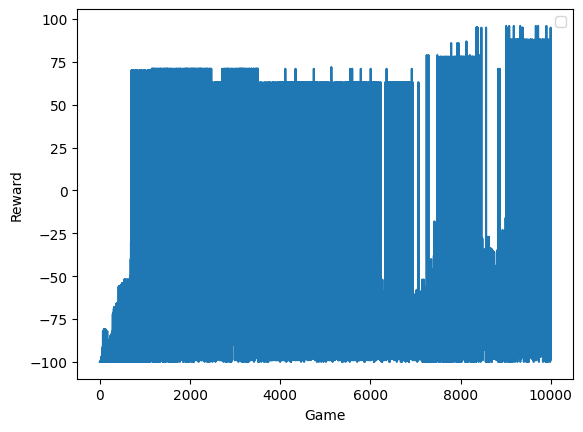

In [60]:
import matplotlib.pyplot as plt

plt.plot(agent.rewards)
plt.xlabel("Game")
plt.ylabel("Reward")
plt.legend()
plt.show()

... observe it play using the trained Q-table ...

In [67]:
qltetris.restart()
agent = QLAgent(qltetris, games=1, epsilon=0, alpha=0.0, gamma=1)
agent.Q_table = np.loadtxt("Q_table.txt")
observe_tetris_with_gui(qltetris, agent)

... and analyze the sparsity of the trained Q-table.

In [ ]:
Q_table = agent.Q_table  # Learned Q-table: rows = states, columns = actions

# Identify states where at least one action has a non-zero Q-value
non_zero_rows_mask = np.any(Q_table != 0, axis=1)

# Count how many states were actually updated during training
num_non_zero_rows = np.sum(non_zero_rows_mask)

print(f"Non-zero rows = {num_non_zero_rows}")

Non-zero rows = 78


### Meaning of `Non-zero rows = 78`

The Q-table has the following structure:

\[
Q_{\text{table}}[\text{state}, \text{action}]
\]

This means that:

- each **row** represents a possible game state;
- each **column** represents a possible action;
- each value estimates how good that action is in that state.

If we obtain the output:

```text
Non-zero rows = 78
```

this means that, out of all possible states, the agent has only updated Q-values for **78 different states**.

In this simplified Tetris environment, the total number of possible states is:

$$
2^{18} = 262,144
$$

Therefore, the agent has learned something about only:

$$
\frac{78}{262144} \approx 0.03\%
$$

of the possible state space.

This shows that even in a very small Tetris environment, the state space is already very large, and the agent only experiences a tiny fraction of it during training.

Most of the Q-table remains unused or empty. This is one of the main limitations of tabular Q-learning: **it does not generalize to unseen states**.

This motivates the transition from classical Q-learning to **Deep Q-learning**, where a neural network is used to approximate the Q-function and generalize across similar states.

**Key takeaway:**  
Only **78 states out of 262,144** were actually updated, showing how sparse the agent’s experience is even in a very small environment.

### Training with a Random Tile Sequence

Train the Q-learning agent with a random tile sequence ...

In [64]:
# Create a new Q-learning Tetris environment.
# random_seed=None means that the tile sequence changes randomly from game to game.
# This gives the agent more varied experiences during training.
qltetris = QLTetris(
    rows=4,
    cols=4,
    max_tiles=50,
    random_seed=None
)

# Create a Q-learning agent.
agent = QLAgent(
    qltetris,
    games=200_000,  # Train for 200,000 games / episodes
    epsilon=0.001,  # Very low exploration rate: 0.1% random actions
    alpha=0.2,      # Learning rate
    gamma=1         # Future rewards are fully considered
)

# Train the agent without GUI.
# The loop keeps calling next_turn() until all 200,000 games are completed.
while agent.next_turn():
    pass

game 100/200000 reward -99.9
game 200/200000 reward -99.3
game 300/200000 reward -99.19
game 400/200000 reward -99.38
game 500/200000 reward -98.91
game 600/200000 reward -98.18
game 700/200000 reward -98.87
game 800/200000 reward -97.96
game 900/200000 reward -98.32
game 1000/200000 reward -98.39
game 1100/200000 reward -97.72
game 1200/200000 reward -98.24
game 1300/200000 reward -96.83
game 1400/200000 reward -98.95
game 1500/200000 reward -97.97
game 1600/200000 reward -98.32
game 1700/200000 reward -97.18
game 1800/200000 reward -98.08
game 1900/200000 reward -97.38
game 2000/200000 reward -97.66
game 2100/200000 reward -97.48
game 2200/200000 reward -97.29
game 2300/200000 reward -97.21
game 2400/200000 reward -96.11
game 2500/200000 reward -97.57
game 2600/200000 reward -96.0
game 2700/200000 reward -96.25
game 2800/200000 reward -97.47
game 2900/200000 reward -95.5
game 3000/200000 reward -96.92
game 3100/200000 reward -95.99
game 3200/200000 reward -96.53
game 3300/200000 rewa

... plot the reward during training ...

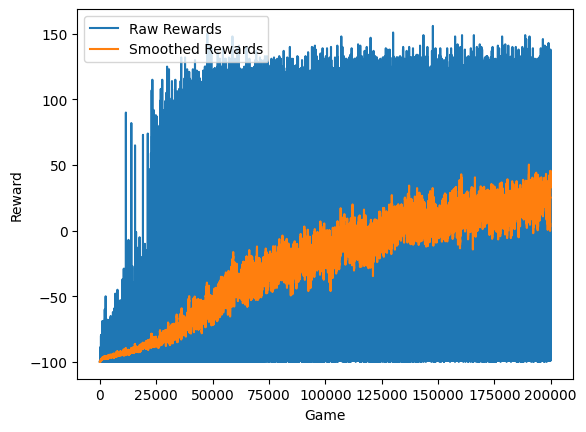

In [ ]:
smoothed_rewards = np.convolve(agent.rewards, np.ones(100) / 100, mode="valid")

plt.plot(agent.rewards, label="Raw Rewards")
plt.plot(smoothed_rewards, label="Smoothed Rewards")
plt.xlabel("Game")
plt.ylabel("Reward")
plt.legend()
plt.show()

... and analyze the sparsity of the trained Q-table.

In [65]:
Q_table = agent.Q_table
non_zero_rows_mask = np.any(Q_table != 0, axis=1)
num_non_zero_rows = np.sum(non_zero_rows_mask)
print(f"Non-zero rows = {num_non_zero_rows}")

Non-zero rows = 21580


## Making an Agent Play Tetris with Deep Q-Learning

### Implementing the Deep Q-Learning Agent

Add the neural networks to the QL agent ...

### DQLAgent: Deep Q-Learning Agent for Tetris

**Class Overview:**
- `DQLAgent` extends `dl.Application` to implement a **Deep Q-Learning agent** that can play Tetris.
- Uses two neural networks:
  - `q_net` (main Q-network, the "student")
  - `target_net` (target network, the "teacher") for stable learning targets.
- Implements a **replay buffer**, epsilon-greedy exploration, and target network synchronization.

---

**__init__ method**
- Initializes the agent with environment, training parameters, network architecture, and replay buffer settings.
- Computes key parameters:
  - `position_num` = number of columns in the Tetris board
  - `orientation_num` = maximum number of orientations across all tiles
  - `action_num` = total possible actions (`position_num * orientation_num`)
  - `state_size` = bits needed to encode board + current tile
  - `state_num` = 2^state_size (number of possible states)
- Sets **epsilon parameters** (`epsilon_max`, `epsilon_min`, `epsilon_scale`) for exploration decay.
- Initializes rewards array and `max_reward` tracker.
- Calls `get_net(hidden_units)` to build `q_net` and `target_net`.
- Sets up **loss function** (MSE) and optimizer (Adam) for Q-learning.

---

**get_net(hidden_units)**
- Creates a **MultiLayer Perceptron**:
  - Input: `state_size`
  - Hidden: `hidden_units`
  - Output: `action_num`
- Returns a built PyTorch neural network.

---

**update_state()**
- Encodes the current game state as a tensor for the neural network.
- Converts the **current tile** into a binary representation.
- Flattens the board to a 1D array and replaces `UNDEFINED` cells with 0.
- Combines tile and board into `state_binary` and stores as a `torch.tensor`.

---

**next_turn()**
- Executes one step in the game, updates Q-networks, and handles game progression.

**If the game is over:**
- Stores the reward in `self.rewards`.
- Every 100 games, prints the average reward and saves the Q-network if improved.
- Restarts the Tetris environment for the next game.
- Updates epsilon with linear decay:

\[
\epsilon = \max(\epsilon_{\min}, \epsilon_{\max} - \text{game} / \epsilon_{\text{scale}})
\]

- Periodically synchronizes `target_net` with `q_net` weights.

**If the game is ongoing:**
1. Chooses an action:
   - With probability `epsilon`, pick a random action.
   - Otherwise, select the action with the highest Q-value from `q_net`.
2. Decodes action into `(new_x, new_orientation)` and teleports the tile.
3. Drops the tile and receives a reward.
4. Updates the agent’s state.
5. Stores the transition `(old_state, action, reward, new_state, gameover)` in the **replay buffer**, maintaining buffer size.
6. If enough samples in the buffer:
   - Sample a mini-batch.
   - Predict next state Q-values with `target_net`.
   - Compute targets using reward + discounted max next Q-value.
   - Apply mask to update only the chosen action.
   - Compute loss, backpropagate, and update `q_net` weights.

**Return Value:**
- `True` if the game continues, `False` if all games are finished.

---

**Key Features and Concepts:**
- **Replay Buffer:** Stores past transitions to stabilize learning and decorrelate samples.
- **Target Network:** Provides stable Q-value targets, updated less frequently than `q_net`.
- **Epsilon-Greedy Exploration:** Balances exploration and exploitation, decays over time.
- **Masked Loss:** Ensures only Q-values for selected actions are updated.
- **Linear epsilon decay:** Gradually reduces randomness as the agent gains experience.
- Supports saving the best-performing Q-network (`q_net.pth`) for evaluation.

In [ ]:
import deeplay as dl
import torch
import numpy as np
import random

class DQLAgent(dl.Application):
    """Deep Q-learning agent to play Tetris."""

    def __init__(self, tetris, games, epsilon_max, epsilon_min, epsilon_scale,
                 alpha, gamma, hidden_units, replay_buffer_size, batch_size,
                 sync_target_game_count, **kwargs):
        """
        Initialize the Deep Q-learning agent with:
        - Tetris environment
        - Training parameters
        - Neural network architecture
        - Replay buffer settings
        """
        self.tetris = tetris
        self.games, self.game = games, 0

        # Number of columns and tile orientations
        self.position_num = self.tetris.cols
        self.orientation_num = np.max([len(tile) for tile in Tetris.TILES])
        self.action_num = self.position_num * self.orientation_num

        # State size: bits needed to encode board + tile type
        self.state_size = (
            self.tetris.cols * self.tetris.rows  # number of cells on the board
            + 1 + np.floor(np.log2(len(Tetris.TILES) - 1)).astype(int)  # tile encoding
        )
        self.state_num = 2 ** self.state_size

        # Epsilon parameters for epsilon-greedy exploration
        self.epsilon_max = epsilon_max
        self.epsilon_min = epsilon_min
        self.epsilon_scale = epsilon_scale
        self.epsilon = self.epsilon_max

        # Learning parameters
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.rewards = np.zeros(games)
        self.max_reward = 0

        # Create main and target neural networks
        self.q_net = self.get_net(hidden_units)
        self.target_net = self.get_net(hidden_units)

        # Initialize the optimizer and loss function
        super().__init__(
            loss=torch.nn.MSELoss(),
            optimizer=torch.optim.Adam(self.q_net.parameters(), lr=0.001),
            **kwargs,
        )

        # Replay buffer to store past transitions
        self.buffer = []
        self.replay_buffer_size = replay_buffer_size
        self.batch_size = batch_size
        self.sync_target_game_count = sync_target_game_count

        # Initialize agent state
        self.update_state()

    def get_net(self, hidden_units):
        """Create instance of MultiLayerPerceptron network."""
        net = dl.MultiLayerPerceptron(
            in_features=self.state_size,
            hidden_features=hidden_units,
            out_features=self.action_num,
        )
        return net.build()

    def update_state(self):
        """Encode current game state as a tensor for the neural network."""
        num_bits = int(np.ceil(np.log2(len(Tetris.TILES))))
        # Convert current tile to binary representation
        tile = bin(self.tetris.current_tile)[2:].zfill(num_bits)
        tile = np.array([int(i) for i in tile])

        # Flatten the board and replace undefined cells with 0
        board = np.copy(self.tetris.board.reshape((-1,))).astype(int)
        board[board == Tetris.UNDEFINED] = 0

        # Combine tile and board into state tensor
        self.state_binary = np.append(tile, board)
        self.state = torch.tensor(self.state_binary, dtype=torch.float32)

    def next_turn(self):
        """Execute one turn in the game and update networks."""
        if self.tetris.gameover:
            # Save rewards and periodically print average reward
            self.rewards[self.game] = self.tetris.reward
            if self.game > 0 and self.game % 100 == 0:
                av_reward = np.mean(self.rewards[self.game - 100:self.game])
                print(f"game {self.game}/{self.games} reward {av_reward}")
                # Save Q-network if improved
                if av_reward > self.max_reward:
                    self.max_reward = av_reward
                    torch.save(self.q_net.state_dict(), "q_net.pth")

            # Restart game if more games remain
            if self.game + 1 < self.games:
                self.game += 1
                # Periodically sync target network with QNet
                if ((len(self.buffer) >= self.replay_buffer_size)
                    and (self.game % self.sync_target_game_count == 0)):
                    self.target_net.load_state_dict(self.q_net.state_dict())
                self.tetris.restart()
                self.update_state()
                # Decay epsilon linearly
                self.epsilon = max(
                    self.epsilon_min,
                    self.epsilon_max - self.game / self.epsilon_scale,
                )
            else:
                return False  # All games finished
        else:
            old_state = self.state

            # Select action with epsilon-greedy strategy
            with torch.no_grad():
                if np.random.rand() < self.epsilon:
                    # Random action
                    action = np.random.randint(self.action_num)
                else:
                    # Best action from QNet
                    state = self.state.view(1, self.state_size)
                    output = self.q_net(state).detach().numpy()[0]
                    action = np.argmax(output)

                # Decode action to position and orientation
                new_x = action // self.position_num
                new_orientation = action % self.orientation_num

                # Apply action and receive reward
                self.tetris.teleport(new_x, new_orientation)
                reward = self.tetris.drop()

                # Update state
                self.update_state()
                new_state = self.state

                # Store transition in replay buffer
                self.buffer.append({
                    "old_state": old_state,
                    "action": action,
                    "reward": reward,
                    "new_state": new_state,
                    "gameover": self.tetris.gameover,
                })
                # Keep buffer size fixed
                if len(self.buffer) >= self.replay_buffer_size + 1:
                    self.buffer.pop(0)

            # Perform training step if enough samples in buffer
            if len(self.buffer) >= self.replay_buffer_size:
                batch = random.sample(self.buffer, self.batch_size)

                # Prepare states and next states
                states, next_states = [], []
                for sample in batch:
                    states.append(sample["old_state"])
                    next_states.append(sample["new_state"])

                # Compute Q-values for next states using TargetNet
                with torch.no_grad():
                    q_hat = self.target_net(torch.stack(next_states, dim=0))

                # Compute target Q-values
                targets = torch.zeros(self.batch_size, self.action_num)
                targets_mask = torch.zeros(self.batch_size, self.action_num)
                for idx, sample in enumerate(batch):
                    if sample["gameover"]:
                        target = sample["reward"]
                    else:
                        target = sample["reward"] + self.gamma * np.nanmax(q_hat[idx, :])
                    targets[idx, sample["action"]] = target
                    targets_mask[idx, sample["action"]] = 1

                # Compute loss and update QNet weights
                self.optimizer.zero_grad()
                preds = self.q_net(torch.stack(states, dim=0))
                masked_preds = preds * targets_mask
                loss = self.loss(masked_preds, targets)
                loss.backward()
                self.optimizer.step()

        return True  # Continue game

... train the deep-Q-learning agent ...

In [ ]:
# Create a simplified Tetris environment with a 4x4 board and a maximum of 50 tiles per game.
# random_seed=None ensures a different sequence of tiles each time.
qltetris = QLTetris(rows=4, cols=4, max_tiles=50, random_seed=None)

# Instantiate a Deep Q-Learning agent to play the environment.
agent = DQLAgent(
    qltetris,                 # The Tetris environment the agent interacts with
    games=10_000,             # Train the agent for 10,000 episodes
    epsilon_max=1,            # Start with full exploration (100% random actions)
    epsilon_min=0.001,        # Minimum exploration rate (0.1%)
    epsilon_scale=5_000,      # Number of games over which epsilon decays from max to min
    alpha=0.001,              # Learning rate for network weight updates
    gamma=1,                  # Discount factor: future rewards are fully considered
    hidden_units=[128, 128],  # Two hidden layers with 128 units each in the neural network
    replay_buffer_size=10_000,# Maximum number of transitions stored in the replay buffer
    batch_size=64,            # Mini-batch size used for training from the replay buffer
    sync_target_game_count=100,# Number of games between updates of the target network
)

game 100/10000 reward -99.72
game 200/10000 reward -99.81
game 300/10000 reward -99.92
game 400/10000 reward -99.77
game 500/10000 reward -99.57
game 600/10000 reward -99.49
game 700/10000 reward -99.65
game 800/10000 reward -99.53
game 900/10000 reward -99.44
game 1000/10000 reward -99.49
game 1100/10000 reward -99.74
game 1200/10000 reward -99.4
game 1300/10000 reward -99.84
game 1400/10000 reward -99.85
game 1500/10000 reward -99.52
game 1600/10000 reward -99.62
game 1700/10000 reward -99.61
game 1800/10000 reward -99.63
game 1900/10000 reward -99.68
game 2000/10000 reward -99.79
game 2100/10000 reward -99.58
game 2200/10000 reward -99.74
game 2300/10000 reward -99.66
game 2400/10000 reward -99.68
game 2500/10000 reward -99.78
game 2600/10000 reward -99.82
game 2700/10000 reward -99.69
game 2800/10000 reward -99.47
game 2900/10000 reward -98.34
game 3000/10000 reward -98.23
game 3100/10000 reward -97.88
game 3200/10000 reward -98.07
game 3300/10000 reward -96.84
game 3400/10000 rewa

... plot the reward during training ...

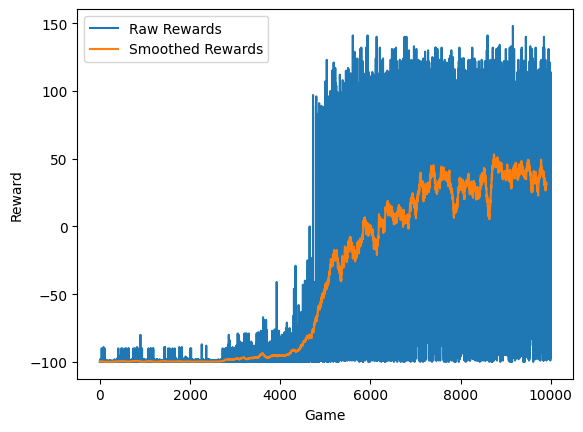

In [ ]:
smoothed_rewards = np.convolve(agent.rewards, np.ones(100) / 100, mode="valid")

plt.plot(agent.rewards, label="Raw Rewards")
plt.plot(smoothed_rewards, label="Smoothed Rewards")
plt.xlabel("Game")
plt.ylabel("Reward")
plt.legend()
plt.show()

... and observe its behavior.

In [ ]:
# Restart the Tetris environment to begin a fresh evaluation
qltetris.restart()

# Instantiate a Deep Q-Learning agent for evaluation
# We set epsilon_max = epsilon_min = 0 to disable exploration: the agent will only exploit its learned policy
agent = DQLAgent(
    qltetris,
    games=3,                  # Only need a few episodes for visualization
    epsilon_max=0,             # No random actions
    epsilon_min=0,             # No random actions
    epsilon_scale=5_000,       # Not used since epsilon is 0
    alpha=0.001,               # Learning rate (won't update since evaluation)
    gamma=1,                   # Full discount for future rewards
    hidden_units=[128, 128],   # Two hidden layers with 128 units each
    replay_buffer_size=10_000, # Replay buffer (not needed for pure evaluation)
    batch_size=64,             # Batch size (not used here)
    sync_target_game_count=100 # Target network update frequency (not used)
)

# Load the previously trained Q-network
model_state_dict = torch.load("q_net.pth")
agent.q_net.load_state_dict(model_state_dict)
agent.target_net.load_state_dict(model_state_dict)

# Observe the agent playing Tetris with the GUI
# Each turn is decided by the trained network without exploration
observe_tetris_with_gui(qltetris, agent)